# Assignment V: Goal-Based Portfolio Optimisation

| | |
|---|---|
| **Tickers** | TCS.NS · HDFCBANK.NS · RELIANCE.NS · SUNPHARMA.NS · ITC.NS |
| **Data Period** | 1 Jan 2014 – 31 Dec 2023 |
| **Horizon** | 20 years |
| **Simulation Paths** | 5,000 per portfolio |

---

**Notebook structure**
1. [Section 1] Data & Statistics *(Member 1)*
2. [Section 2] Monte Carlo Simulation Engine *(Member 2)*
3. [Section 3] Brute-Force Optimisation *(Member 3)*
4. [Section 4] Results & Comparison
5. [Section 5] Bonus — Continuous SciPy Optimiser *(Member 4)*

---
## Section 1 — Data & Statistics

In [1]:
IMAGES_DIR = "images"

In [2]:
from data import (
    TICKERS, START_DATE, END_DATE, HORIZON_YEARS,
    download_prices, compute_log_returns, compute_annualised_stats,
    build_savings_schedule, print_stats_table, print_savings_schedule,
    get_returns, get_stats, get_cov_matrix, get_savings
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

print('All imports OK')

All imports OK


In [3]:
# Download Prices
prices = download_prices()

print(f'\nPrice DataFrame shape : {prices.shape}')
prices.tail(3)

Period : 2014-01-01  ->  2023-12-31
Downloaded 2465 trading days  |  5 tickers  |  2014-01-01 to 2023-12-29

Price DataFrame shape : (2465, 5)


Ticker,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS
Date,,,,,
2023-12-27,3549.456299,828.971863,1283.922119,1221.990845,403.042572
2023-12-28,3538.932129,829.920837,1293.203369,1231.455078,409.214752
2023-12-29,3532.878174,831.867615,1282.979126,1228.820679,407.451263


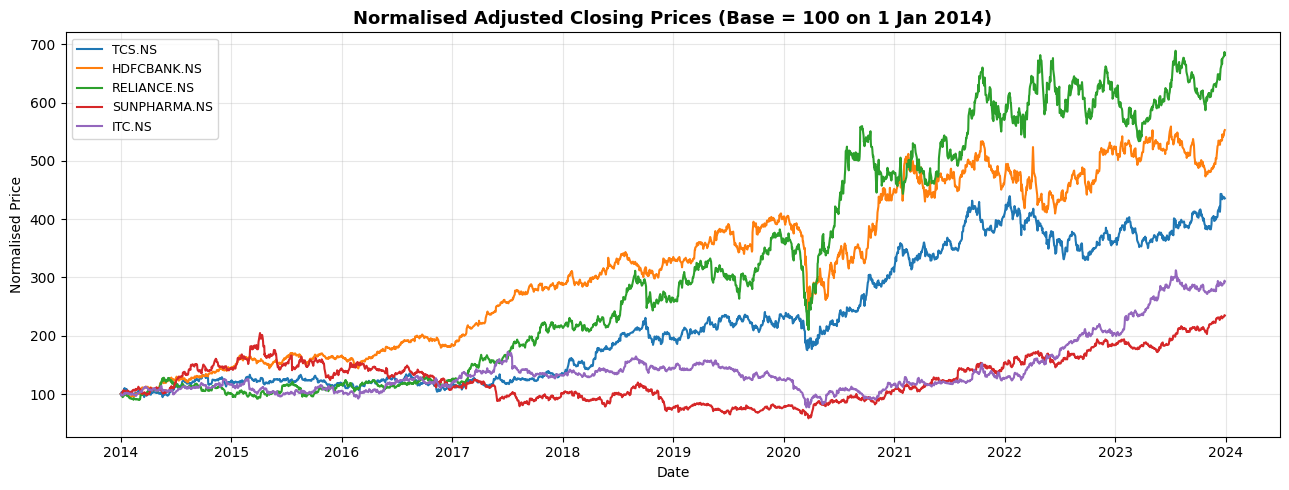

Figure saved -> price_history.png


In [4]:
# Price History Chart
fig, ax = plt.subplots(figsize=(13, 5))

# Normalise prices to 100 on the first date so all series are comparable
normalised = prices / prices.iloc[0] * 100

for ticker in TICKERS:
    ax.plot(normalised.index, normalised[ticker], label=ticker, linewidth=1.5)

ax.set_title('Normalised Adjusted Closing Prices (Base = 100 on 1 Jan 2014)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Price')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/price_history.png', dpi=150)
plt.show()
print('Figure saved -> price_history.png')

In [5]:
# Compute Log Returns
log_returns = compute_log_returns(prices)

print(f'Log-returns shape : {log_returns.shape}')
print(f'Date range        : {log_returns.index[0].date()}  ->  {log_returns.index[-1].date()}')
log_returns.describe().round(6)

Log-returns shape : (2464, 5)
Date range        : 2014-01-02  ->  2023-12-29


Ticker,TCS.NS,HDFCBANK.NS,RELIANCE.NS,SUNPHARMA.NS,ITC.NS
count,2464.000000,2464.000000,2464.000000,2464.000000,2464.000000
mean,0.000597,0.000694,0.000779,0.000347,0.000437
std,0.015145,0.014148,0.017493,0.018812,0.016051
min,-0.098830,-0.134754,-0.141032,-0.163202,-0.137130
25%,-0.006984,-0.006302,-0.008754,-0.009301,-0.007535
50%,0.000477,0.000620,0.000599,0.000222,0.000294
75%,0.008686,0.007510,0.010026,0.009837,0.008681
max,0.093901,0.109747,0.137307,0.104469,0.095725


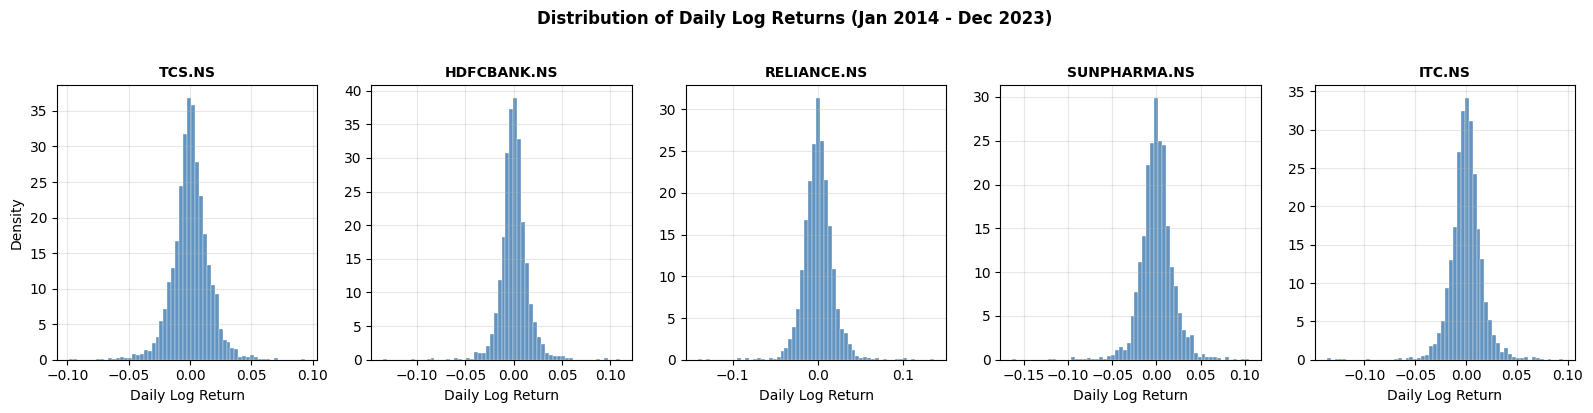

Figure saved -> return_distributions.png


In [6]:
# Daily Return Distributions
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)

for ax, ticker in zip(axes, TICKERS):
    ax.hist(log_returns[ticker], bins=60, color='steelblue', edgecolor='white',
            linewidth=0.3, density=True, alpha=0.85)
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Daily Log Return')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Density')
fig.suptitle('Distribution of Daily Log Returns (Jan 2014 - Dec 2023)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> return_distributions.png')

In [7]:
# Annualised Statistics
mu, std, cov = compute_annualised_stats(log_returns)

print_stats_table(TICKERS, mu, std, cov)

# Also display as a clean DataFrame for the notebook
stats_df = pd.DataFrame({'Ticker': TICKERS,
                          'Ann. Expected Return': mu,
                          'Ann. Std Deviation'  : std})
stats_df = stats_df.set_index('Ticker')
stats_df.style.format({'Ann. Expected Return': '{:.2%}',
                        'Ann. Std Deviation'  : '{:.2%}'})


Ticker           Ann. Return  Ann. Std Dev
-------------------------------------------------------
TCS.NS               15.05%       24.04%
HDFCBANK.NS          17.49%       22.46%
RELIANCE.NS          19.62%       27.77%
SUNPHARMA.NS          8.73%       29.86%
ITC.NS               11.00%       25.48%

Annualised Covariance Matrix:
               TCS.NS  HDFCBANK.NS  RELIANCE.NS  SUNPHARMA.NS   ITC.NS
TCS.NS       0.057798     0.012586     0.016356      0.012618 0.010942
HDFCBANK.NS  0.012586     0.050443     0.025463      0.013180 0.016446
RELIANCE.NS  0.016356     0.025463     0.077114      0.018667 0.016614
SUNPHARMA.NS 0.012618     0.013180     0.018667      0.089183 0.013992
ITC.NS       0.010942     0.016446     0.016614      0.013992 0.064921

Correlation Matrix (derived from cov):
              TCS.NS  HDFCBANK.NS  RELIANCE.NS  SUNPHARMA.NS  ITC.NS
TCS.NS        1.0000      -0.3776      -0.2180       -0.2898 -0.3919
HDFCBANK.NS  -0.3776       1.0000       0.1992       -0.3695

,Ann. Expected Return,Ann. Std Deviation
Ticker,,
TCS.NS,15.05%,24.04%
HDFCBANK.NS,17.49%,22.46%
RELIANCE.NS,19.62%,27.77%
SUNPHARMA.NS,8.73%,29.86%
ITC.NS,11.00%,25.48%


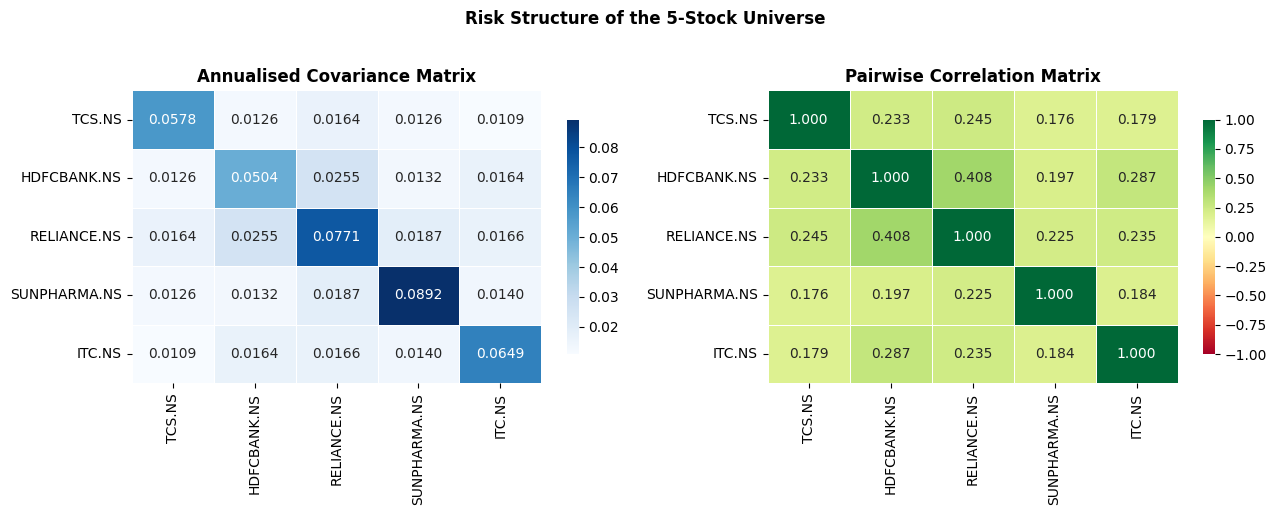

Figure saved -> covariance_correlation.png


In [8]:
# Covariance & Correlation Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Covariance heatmap
cov_df = pd.DataFrame(cov, index=TICKERS, columns=TICKERS)
sns.heatmap(cov_df, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_title('Annualised Covariance Matrix', fontweight='bold')

# Correlation heatmap
corr_matrix = np.corrcoef(log_returns.T)   # correlation from raw daily returns
corr_df = pd.DataFrame(corr_matrix, index=TICKERS, columns=TICKERS)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Pairwise Correlation Matrix', fontweight='bold')

plt.suptitle('Risk Structure of the 5-Stock Universe', fontsize=12,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/covariance_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> covariance_correlation.png')


Savings Schedule (₹ per year):
  Year  1 : ₹     240,000
  Year  2 : ₹     249,600
  Year  3 : ₹     259,584
  ...      (growing at 4% p.a.)
  Year 18 : ₹     467,496
  Year 19 : ₹     486,196
  Year 20 : ₹     505,644

  Total contributions over 20 years: ₹7,146,739


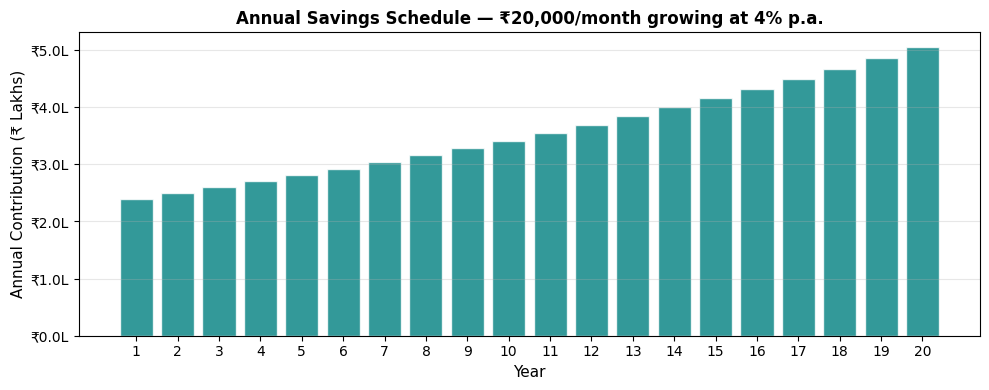

Figure saved -> savings_schedule.png


In [9]:
# Savings Schedule
savings = build_savings_schedule()
print_savings_schedule(savings)

# Chart
fig, ax = plt.subplots(figsize=(10, 4))
years = np.arange(1, HORIZON_YEARS + 1)
ax.bar(years, savings / 1e5, color='teal', alpha=0.8, edgecolor='white')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Annual Contribution (₹ Lakhs)', fontsize=11)
ax.set_title('Annual Savings Schedule — ₹20,000/month growing at 4% p.a.',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}L'))
ax.set_xticks(years)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/savings_schedule.png', dpi=150)
plt.show()
print('Figure saved -> savings_schedule.png')

In [10]:
print('=== Final Confirmation ===\n')
print(f'  mu      : shape={mu.shape},  dtype={mu.dtype}')
print(f'  std     : shape={std.shape}, dtype={std.dtype}')
print(f'  cov     : shape={cov.shape}, dtype={cov.dtype}')
print(f'  savings : shape={savings.shape}, dtype={savings.dtype}')
print()
print('  mu values (annualised expected returns):')
for t, m in zip(TICKERS, mu):
    print(f'    {t:<15} -> {m:.4%}')

=== Final Confirmation ===

  mu      : shape=(5,),  dtype=float64
  std     : shape=(5,), dtype=float64
  cov     : shape=(5, 5), dtype=float64
  savings : shape=(20,), dtype=float64

  mu values (annualised expected returns):
    TCS.NS          -> 15.0485%
    HDFCBANK.NS     -> 17.4858%
    RELIANCE.NS     -> 19.6233%
    SUNPHARMA.NS    -> 8.7321%
    ITC.NS          -> 11.0024%


---
## Section 2 — Monte Carlo Simulation Engine

In [11]:
from simulator import (
    simulate_portfolio,
    compute_success_probability,
    print_simulation_summary,
    BORROWING_RATE, HORIZON_YEARS, N_PATHS
)
 
# Goal sequences as defined in the assignment
GOALS_A = {3: 1_500_000, 7: 2_500_000, 12: 3_000_000}   # intermediate only
GOALS_B = {8: 1_000_000, 12: 2_000_000, 16: 4_000_000}  # intermediate only
TERMINAL_GOAL = 15_000_000                               # ₹1.5 Crore
 
print(f"Borrowing rate : {BORROWING_RATE:.0%}")
print(f"Horizon        : {HORIZON_YEARS} years")
print(f"Paths per sim  : {N_PATHS:,}")
print(f"\nGoal Sequence A : {GOALS_A}")
print(f"Goal Sequence B : {GOALS_B}")
print(f"Terminal Goal   : ₹{TERMINAL_GOAL:,.0f}")

Borrowing rate : 12%
Horizon        : 20 years
Paths per sim  : 5,000

Goal Sequence A : {3: 1500000, 7: 2500000, 12: 3000000}
Goal Sequence B : {8: 1000000, 12: 2000000, 16: 4000000}
Terminal Goal   : ₹15,000,000


In [12]:
# Smoke test on equal-weight portfolio
weights_equal = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Sequence A
final_eq_A = simulate_portfolio(
    weights_equal,
    mu,
    cov,
    savings,
    goals={**GOALS_A, 20: TERMINAL_GOAL},
    n_paths=N_PATHS,
    seed=42,
)
print_simulation_summary(
    weights_equal,
    TICKERS,
    final_eq_A,
    terminal_goal=TERMINAL_GOAL,
    goals={**GOALS_A, 20: TERMINAL_GOAL},
)

# Sequence B
final_eq_B = simulate_portfolio(
    weights_equal,
    mu,
    cov,
    savings,
    goals={**GOALS_B, 20: TERMINAL_GOAL},
    n_paths=N_PATHS,
    seed=42,
)
print_simulation_summary(
    weights_equal,
    TICKERS,
    final_eq_B,
    terminal_goal=TERMINAL_GOAL,
    goals={**GOALS_B, 20: TERMINAL_GOAL},
)


Simulation Summary
-------------------------------------------------------
Portfolio Weights:
  TCS.NS          : 0.20
  HDFCBANK.NS     : 0.20
  RELIANCE.NS     : 0.20
  SUNPHARMA.NS    : 0.20
  ITC.NS          : 0.20

Goal Schedule : {3: 1500000, 7: 2500000, 12: 3000000, 20: 15000000}
Terminal Goal : ₹15,000,000
-------------------------------------------------------
  Paths simulated     : 5,000
  Mean final value    : ₹    -25,312,277
  Median final value  : ₹    -25,369,091
  5th percentile      : ₹    -26,490,539
  95th percentile     : ₹    -23,922,227
  Success probability : 0.00%

Simulation Summary
-------------------------------------------------------
Portfolio Weights:
  TCS.NS          : 0.20
  HDFCBANK.NS     : 0.20
  RELIANCE.NS     : 0.20
  SUNPHARMA.NS    : 0.20
  ITC.NS          : 0.20

Goal Schedule : {8: 1000000, 12: 2000000, 16: 4000000, 20: 15000000}
Terminal Goal : ₹15,000,000
-------------------------------------------------------
  Paths simulated     : 5,000

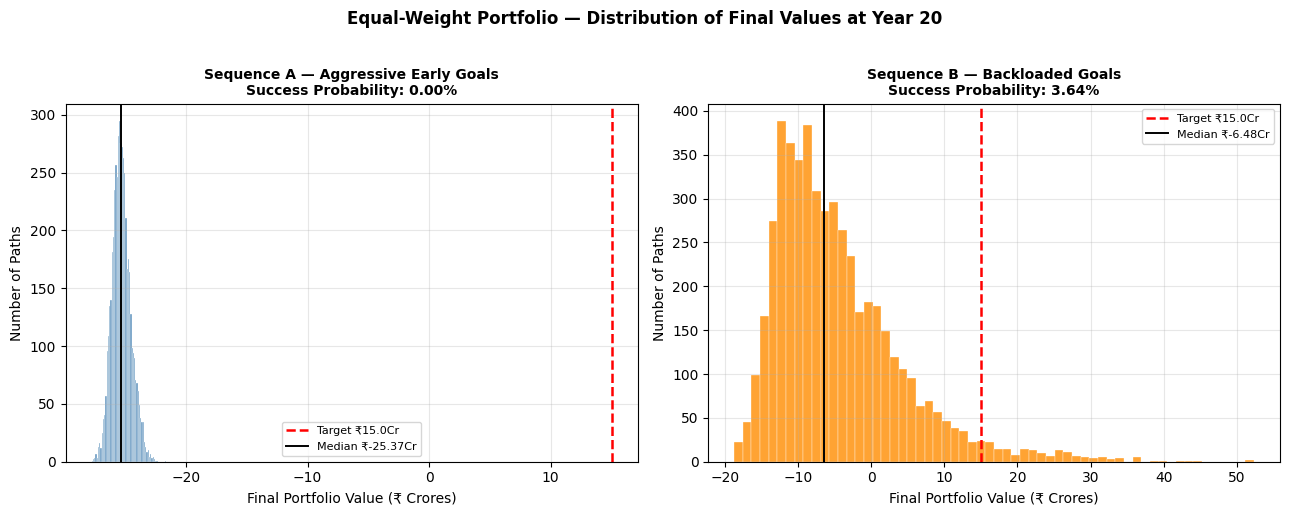

Figure saved -> simulation_distributions.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, final_vals, label, color in zip(
    axes,
    [final_eq_A, final_eq_B],
    ["Sequence A — Aggressive Early Goals", "Sequence B — Backloaded Goals"],
    ["steelblue", "darkorange"],
):
    ax.hist(
        final_vals / 1e6,
        bins=60,
        color=color,
        alpha=0.8,
        edgecolor="white",
        linewidth=0.3,
    )
    ax.axvline(
        TERMINAL_GOAL / 1e6,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label=f"Target ₹{TERMINAL_GOAL / 1e6:.1f}Cr",
    )
    ax.axvline(
        np.median(final_vals) / 1e6,
        color="black",
        linestyle="-",
        linewidth=1.4,
        label=f"Median ₹{np.median(final_vals) / 1e6:.2f}Cr",
    )
    prob = compute_success_probability(final_vals, TERMINAL_GOAL)
    ax.set_title(
        f"{label}\nSuccess Probability: {prob:.2%}", fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Final Portfolio Value (₹ Crores)")
    ax.set_ylabel("Number of Paths")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Equal-Weight Portfolio — Distribution of Final Values at Year 20",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/simulation_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> simulation_distributions.png')

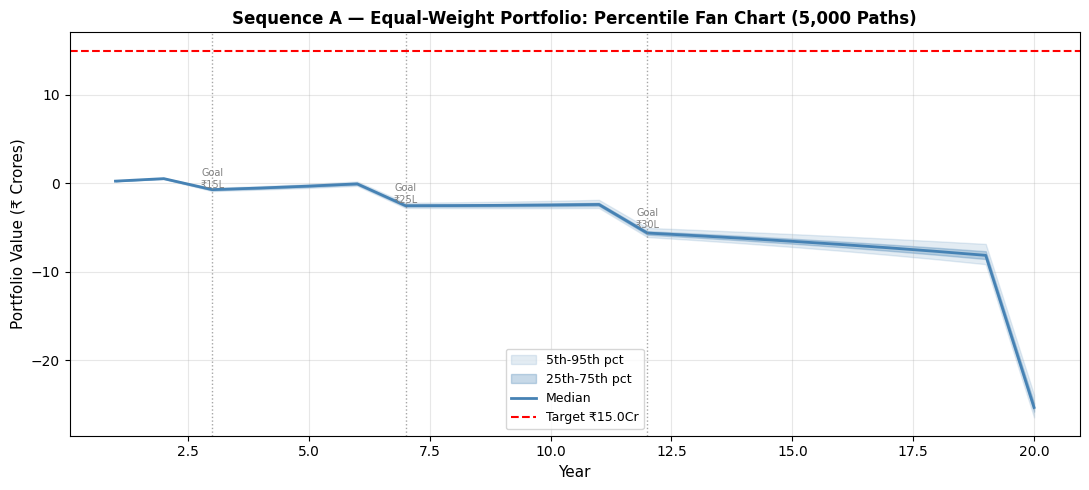

Figure saved -> fan_chart_seqA.png


In [14]:
# Rebuild year-by-year percentile bands for Sequence A (equal weight) for visualisation
def simulate_portfolio_yearly(
    weights, mu, cov, savings, goals, n_paths=N_PATHS, seed=None
):
    """Same logic as simulate_portfolio but records portfolio value at every year."""
    if seed is not None:
        np.random.seed(seed)

    mu_p = float(weights @ mu)
    sigma_p = float(np.sqrt(weights @ cov @ weights))

    portfolio = np.zeros(n_paths)
    loan = np.zeros(n_paths)
    history = np.zeros((HORIZON_YEARS, n_paths))  # store end-of-year values

    for year in range(1, HORIZON_YEARS + 1):
        annual_returns = np.random.normal(mu_p, sigma_p, n_paths)
        portfolio = portfolio * (1 + annual_returns)
        portfolio += savings[year - 1]

        if year in goals:
            target = goals[year]
            meets = portfolio >= target
            shortfall = np.where(~meets, target - portfolio, 0.0)
            loan += shortfall
            portfolio = np.where(meets, portfolio - target, 0.0)

        loan = loan * (1 + BORROWING_RATE)
        repayment = np.minimum(portfolio, loan)
        portfolio = portfolio - repayment
        loan = loan - repayment

        history[year - 1] = portfolio - loan

    return history


history_A = simulate_portfolio_yearly(
    weights_equal,
    mu,
    cov,
    savings,
    goals={**GOALS_A, 20: TERMINAL_GOAL},
    n_paths=N_PATHS,
    seed=42,
)

years = np.arange(1, HORIZON_YEARS + 1)
p5 = np.percentile(history_A, 5, axis=1) / 1e6
p25 = np.percentile(history_A, 25, axis=1) / 1e6
p50 = np.percentile(history_A, 50, axis=1) / 1e6
p75 = np.percentile(history_A, 75, axis=1) / 1e6
p95 = np.percentile(history_A, 95, axis=1) / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(years, p5, p95, alpha=0.15, color="steelblue", label="5th-95th pct")
ax.fill_between(years, p25, p75, alpha=0.30, color="steelblue", label="25th-75th pct")
ax.plot(years, p50, color="steelblue", linewidth=2.0, label="Median")
ax.axhline(
    TERMINAL_GOAL / 1e6,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Target ₹{TERMINAL_GOAL / 1e6:.1f}Cr",
)

# Mark goal years
for yr, amt in GOALS_A.items():
    ax.axvline(yr, color="grey", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.annotate(
        f"Goal\n₹{amt / 1e5:.0f}L",
        xy=(yr, p95[yr - 1]),
        fontsize=7,
        ha="center",
        color="grey",
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Portfolio Value (₹ Crores)", fontsize=11)
ax.set_title(
    "Sequence A — Equal-Weight Portfolio: Percentile Fan Chart (5,000 Paths)",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/fan_chart_seqA.png', dpi=150)
plt.show()
print('Figure saved -> fan_chart_seqA.png')

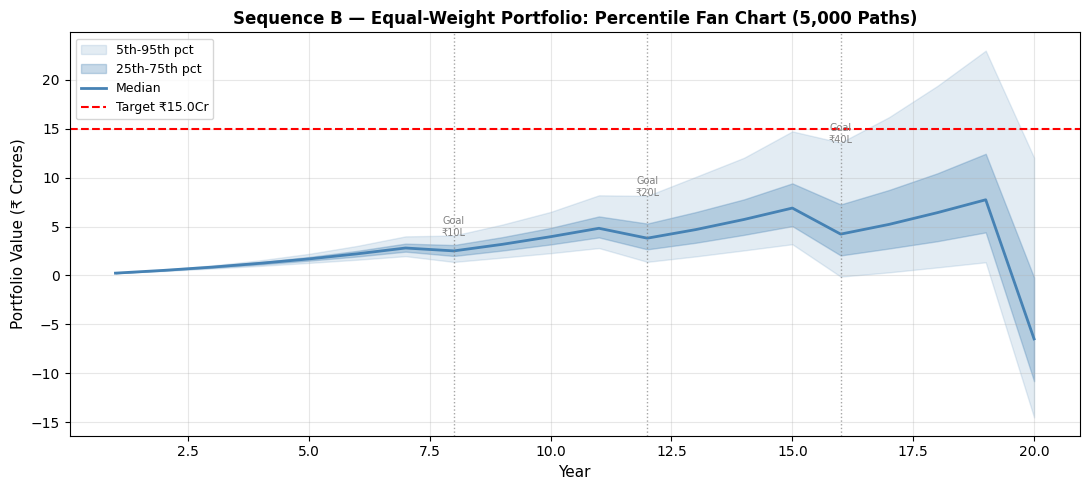

Figure saved -> fan_chart_seqB.png


In [15]:
history_B = simulate_portfolio_yearly(
    weights_equal,
    mu,
    cov,
    savings,
    goals={**GOALS_B, 20: TERMINAL_GOAL},
    n_paths=N_PATHS,
    seed=42,
)

years = np.arange(1, HORIZON_YEARS + 1)
p5 = np.percentile(history_B, 5, axis=1) / 1e6
p25 = np.percentile(history_B, 25, axis=1) / 1e6
p50 = np.percentile(history_B, 50, axis=1) / 1e6
p75 = np.percentile(history_B, 75, axis=1) / 1e6
p95 = np.percentile(history_B, 95, axis=1) / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(years, p5, p95, alpha=0.15, color="steelblue", label="5th-95th pct")
ax.fill_between(years, p25, p75, alpha=0.30, color="steelblue", label="25th-75th pct")
ax.plot(years, p50, color="steelblue", linewidth=2.0, label="Median")
ax.axhline(
    TERMINAL_GOAL / 1e6,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Target ₹{TERMINAL_GOAL / 1e6:.1f}Cr",
)

# Mark goal years
for yr, amt in GOALS_B.items():
    ax.axvline(yr, color="grey", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.annotate(
        f"Goal\n₹{amt / 1e5:.0f}L",
        xy=(yr, p95[yr - 1]),
        fontsize=7,
        ha="center",
        color="grey",
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Portfolio Value (₹ Crores)", fontsize=11)
ax.set_title(
    "Sequence B — Equal-Weight Portfolio: Percentile Fan Chart (5,000 Paths)",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/fan_chart_seqB.png', dpi=150)
plt.show()
print("Figure saved -> fan_chart_seqB.png")

In [16]:
print(f"final_eq_A shape : {final_eq_A.shape}  dtype: {final_eq_A.dtype}")
print(f"final_eq_B shape : {final_eq_B.shape}  dtype: {final_eq_B.dtype}")
print(f"\nSuccess prob — Seq A (equal weight) : {compute_success_probability(final_eq_A, TERMINAL_GOAL):.2%}")
print(f"Success prob — Seq B (equal weight) : {compute_success_probability(final_eq_B, TERMINAL_GOAL):.2%}")

final_eq_A shape : (5000,)  dtype: float64
final_eq_B shape : (5000,)  dtype: float64

Success prob — Seq A (equal weight) : 0.00%
Success prob — Seq B (equal weight) : 3.64%


---
## Section 3 — Brute-Force Optimisation

In [17]:
from optimiser import (
    generate_valid_combinations,
    run_optimisation,
    print_optimal_portfolio,
    print_top_n,
    DISCRETE_WEIGHTS,
)

# Confirm combination count before running the full optimisation
combos = generate_valid_combinations()
print(f"Discrete weight grid : {DISCRETE_WEIGHTS}")
print(f"Securities           : {len(TICKERS)}")
print(f"Total candidates     : {len(DISCRETE_WEIGHTS) ** len(TICKERS)} (5^5)")
print(f"Valid combinations   : {len(combos)} (sum == 1.0)")

Discrete weight grid : [0.0, 0.25, 0.5, 0.75, 1.0]
Securities           : 5
Total candidates     : 3125 (5^5)
Valid combinations   : 70 (sum == 1.0)


In [18]:
# Full goal dict includes the terminal goal at Year 20
goals_A_full = {**GOALS_A, 20: TERMINAL_GOAL}

print("Sequence A -- Aggressive Early Goals")
print(f"Goals : {goals_A_full}\n")

best_w_A, best_p_A, results_A = run_optimisation(
    mu,
    cov,
    savings,
    goals=goals_A_full,
    n_paths=N_PATHS,
    seed=42,
    verbose=True,
)

print_optimal_portfolio(best_w_A, best_p_A, TICKERS, label="Sequence A")

Sequence A -- Aggressive Early Goals
Goals : {3: 1500000, 7: 2500000, 12: 3000000, 20: 15000000}

Total valid combinations : 70
Paths per combination    : 5,000
Terminal goal            : Rs 15,000,000
Running optimisation...

  Evaluated  10/70 combinations...
  Evaluated  20/70 combinations...
  Evaluated  30/70 combinations...
  Evaluated  40/70 combinations...
  Evaluated  50/70 combinations...
  Evaluated  60/70 combinations...
  Evaluated  70/70 combinations...

Optimisation complete.
Best success probability : 0.00%
Best weights             : [0. 0. 0. 0. 1.]

Optimal Portfolio -- Sequence A
-------------------------------------------------------
  TCS.NS          : 0.00  
  HDFCBANK.NS     : 0.00  
  RELIANCE.NS     : 0.00  
  SUNPHARMA.NS    : 0.00  
  ITC.NS          : 1.00  ####################

  Success Probability : 0.00%


In [19]:
goals_B_full = {**GOALS_B, 20: TERMINAL_GOAL}

print("Sequence B -- Backloaded Goals")
print(f"Goals : {goals_B_full}\n")

best_w_B, best_p_B, results_B = run_optimisation(
    mu,
    cov,
    savings,
    goals=goals_B_full,
    n_paths=N_PATHS,
    seed=42,
    verbose=True,
)

print_optimal_portfolio(best_w_B, best_p_B, TICKERS, label="Sequence B")

Sequence B -- Backloaded Goals
Goals : {8: 1000000, 12: 2000000, 16: 4000000, 20: 15000000}

Total valid combinations : 70
Paths per combination    : 5,000
Terminal goal            : Rs 15,000,000
Running optimisation...

  Evaluated  10/70 combinations...
  Evaluated  20/70 combinations...
  Evaluated  30/70 combinations...
  Evaluated  40/70 combinations...
  Evaluated  50/70 combinations...
  Evaluated  60/70 combinations...
  Evaluated  70/70 combinations...

Optimisation complete.
Best success probability : 28.68%
Best weights             : [0. 0. 1. 0. 0.]

Optimal Portfolio -- Sequence B
-------------------------------------------------------
  TCS.NS          : 0.00  
  HDFCBANK.NS     : 0.00  
  RELIANCE.NS     : 1.00  ####################
  SUNPHARMA.NS    : 0.00  
  ITC.NS          : 0.00  

  Success Probability : 28.68%


In [20]:
print_top_n(results_A, n=10, label="Sequence A")
print_top_n(results_B, n=10, label="Sequence B")


Top 10 Portfolios -- Sequence A
---------------------------------------------------------------------------
Rank  TCS.NS        HDFCBANK.NS   RELIANCE.NS   SUNPHARMA.NS  ITC.NS         Success Prob
---------------------------------------------------------------------------
  1   0.00          0.00          0.00          0.00          1.00                 0.00%
  2   0.25          0.00          0.75          0.00          0.00                 0.00%
  3   0.25          0.25          0.50          0.00          0.00                 0.00%
  4   0.25          0.25          0.25          0.25          0.00                 0.00%
  5   0.25          0.25          0.25          0.00          0.25                 0.00%
  6   0.25          0.25          0.00          0.50          0.00                 0.00%
  7   0.25          0.25          0.00          0.25          0.25                 0.00%
  8   0.25          0.25          0.00          0.00          0.50                 0.00%
  9   0.25   

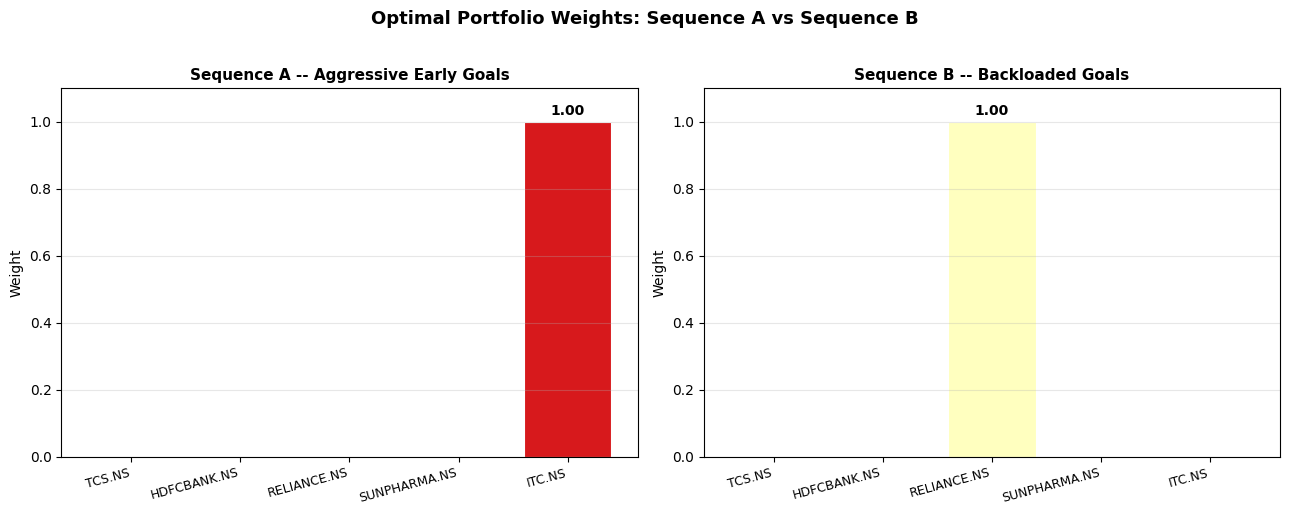

Figure saved -> optimal_weights_comparison.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]

for ax, best_w, label, color_set in zip(
    axes,
    [best_w_A, best_w_B],
    ["Sequence A -- Aggressive Early Goals", "Sequence B -- Backloaded Goals"],
    [colors, colors],
):
    bars = ax.bar(TICKERS, best_w, color=color_set, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, best_w):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Weight")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xticklabels(TICKERS, rotation=15, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Optimal Portfolio Weights: Sequence A vs Sequence B",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/optimal_weights_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved -> optimal_weights_comparison.png')

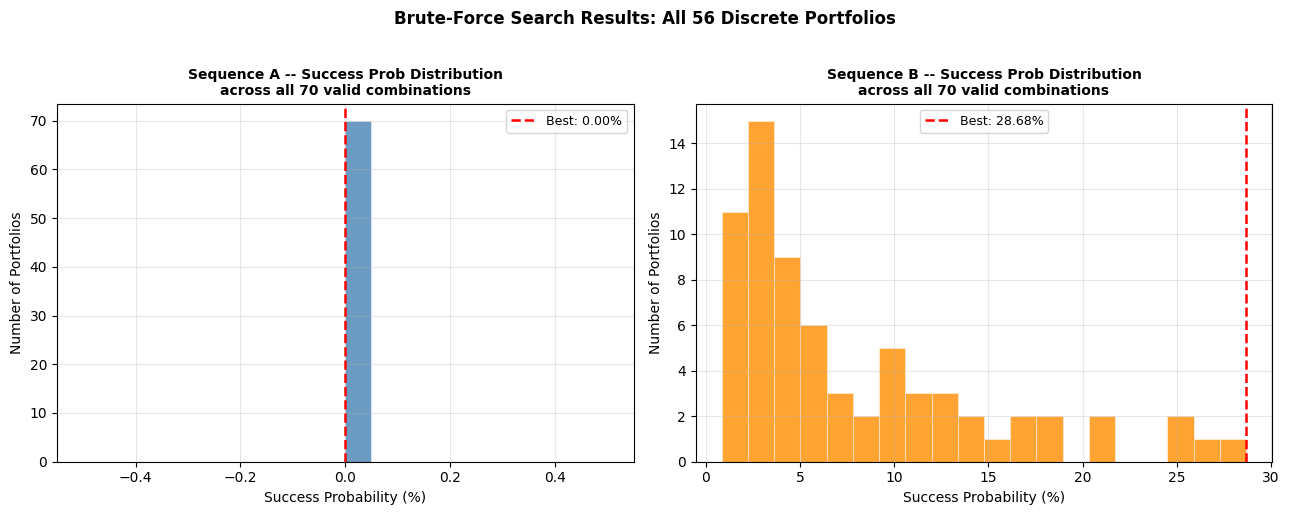

Figure saved -> success_prob_distribution.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, results_df, best_p, label, color in zip(
    axes,
    [results_A, results_B],
    [best_p_A, best_p_B],
    ["Sequence A", "Sequence B"],
    ["steelblue", "darkorange"],
):
    probs = results_df["success_prob"].values * 100
    ax.hist(probs, bins=20, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.axvline(
        best_p * 100,
        color="red",
        linestyle="--",
        linewidth=1.8,
        label=f"Best: {best_p:.2%}",
    )
    ax.set_xlabel("Success Probability (%)")
    ax.set_ylabel("Number of Portfolios")
    ax.set_title(
        f"{label} -- Success Prob Distribution\nacross all {len(results_df)} valid combinations",
        fontsize=10,
        fontweight="bold",
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Brute-Force Search Results: All 56 Discrete Portfolios",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/success_prob_distribution.png', dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> success_prob_distribution.png")

In [23]:
summary = pd.DataFrame(
    {
        "Metric": [
            "TCS.NS",
            "HDFCBANK.NS",
            "RELIANCE.NS",
            "SUNPHARMA.NS",
            "ITC.NS",
            "Success Probability",
        ],
        "Sequence A": [f"{w:.2f}" for w in best_w_A] + [f"{best_p_A:.2%}"],
        "Sequence B": [f"{w:.2f}" for w in best_w_B] + [f"{best_p_B:.2%}"],
    }
)
summary = summary.set_index("Metric")
print("\nOptimal Portfolio Summary")
print(summary.to_string())
summary


Optimal Portfolio Summary
                    Sequence A Sequence B
Metric                                   
TCS.NS                    0.00       0.00
HDFCBANK.NS               0.00       0.00
RELIANCE.NS               0.00       1.00
SUNPHARMA.NS              0.00       0.00
ITC.NS                    1.00       0.00
Success Probability      0.00%     28.68%


,Sequence A,Sequence B
Metric,,
TCS.NS,0.00,0.00
HDFCBANK.NS,0.00,0.00
RELIANCE.NS,0.00,1.00
SUNPHARMA.NS,0.00,0.00
ITC.NS,1.00,0.00
Success Probability,0.00%,28.68%


---
## Section 4 — Results and Comparison
> Consolidates all outputs from Sections 1-3 into a unified analysis.
> Covers: optimal portfolio compositions, success probabilities, fan charts
> for the optimal portfolios, and a discussion of why the two goal sequences
> lead to different optimal allocations.

In [24]:
history_opt_A = simulate_portfolio_yearly(
    best_w_A, mu, cov, savings,
    goals=goals_A_full,
    n_paths=N_PATHS, seed=42
)
 
history_opt_B = simulate_portfolio_yearly(
    best_w_B, mu, cov, savings,
    goals=goals_B_full,
    n_paths=N_PATHS, seed=42
)
 
print("Optimal portfolio trajectories simulated.")
print(f"history_opt_A shape : {history_opt_A.shape}")
print(f"history_opt_B shape : {history_opt_B.shape}")

Optimal portfolio trajectories simulated.
history_opt_A shape : (20, 5000)
history_opt_B shape : (20, 5000)


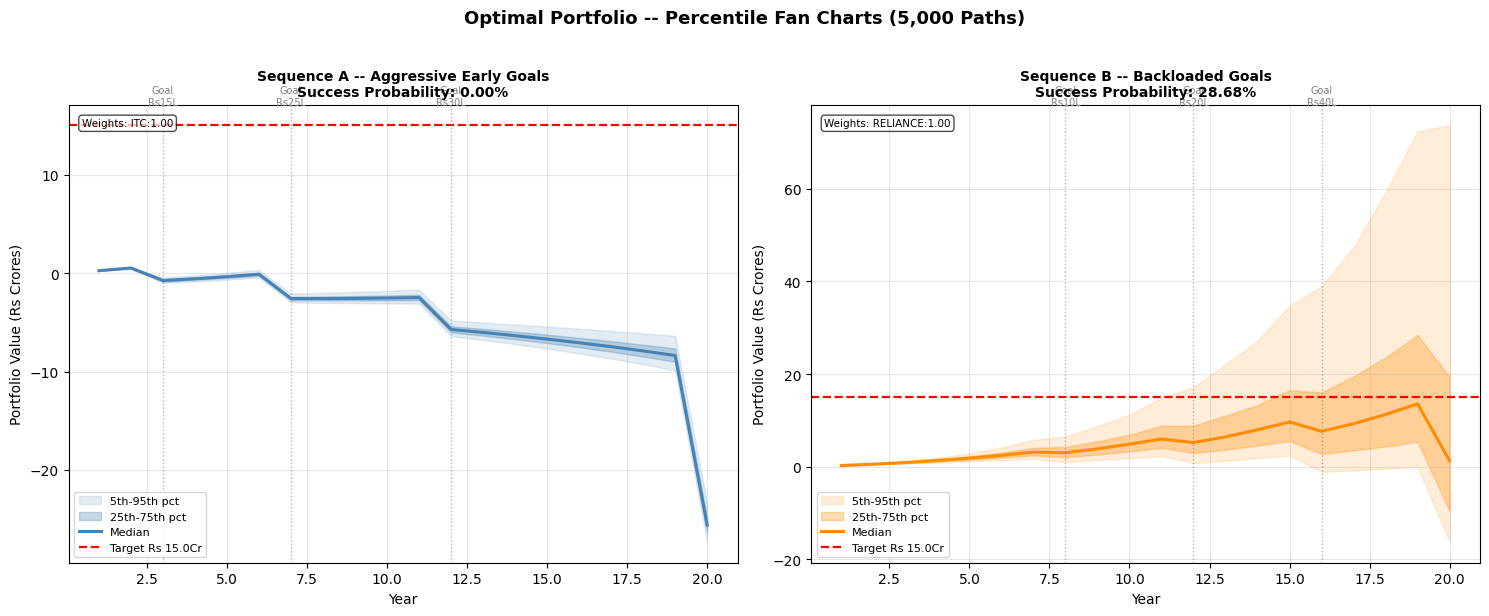

Figure saved -> fan_charts_optimal.png


In [31]:
years = np.arange(1, HORIZON_YEARS + 1)
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
 
plot_config = [
    (history_opt_A, goals_A_full, best_w_A, best_p_A, "Sequence A -- Aggressive Early Goals", "steelblue"),
    (history_opt_B, goals_B_full, best_w_B, best_p_B, "Sequence B -- Backloaded Goals",        "darkorange"),
]
 
for ax, (history, goals_full, best_w, best_p, label, color) in zip(axes, plot_config):
    p5  = np.percentile(history, 5,  axis=1) / 1e6
    p25 = np.percentile(history, 25, axis=1) / 1e6
    p50 = np.percentile(history, 50, axis=1) / 1e6
    p75 = np.percentile(history, 75, axis=1) / 1e6
    p95 = np.percentile(history, 95, axis=1) / 1e6
 
    ax.fill_between(years, p5,  p95, alpha=0.15, color=color, label="5th-95th pct")
    ax.fill_between(years, p25, p75, alpha=0.30, color=color, label="25th-75th pct")
    ax.plot(years, p50, color=color, linewidth=2.2, label="Median")
    ax.axhline(TERMINAL_GOAL / 1e6, color="red", linestyle="--",
               linewidth=1.6, label=f"Target Rs {TERMINAL_GOAL/1e6:.1f}Cr")
 
    # Mark each intermediate goal year with a vertical line and annotation
    for yr, amt in goals_full.items():
        if yr < 20:
            ax.axvline(yr, color="grey", linestyle=":", linewidth=1.0, alpha=0.6)
            ax.annotate(
                f"Goal\nRs{amt/1e5:.0f}L",
                xy=(yr, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else p95.max()),
                fontsize=7, ha="center", color="grey",
            )
 
    # Annotate optimal weights inside the chart
    weight_str = "  ".join(
        f"{t.split('.')[0]}:{w:.2f}"
        for t, w in zip(TICKERS, best_w) if w > 0
    )
    ax.text(0.02, 0.97, f"Weights: {weight_str}",
            transform=ax.transAxes, fontsize=7.5, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
 
    ax.set_title(f"{label}\nSuccess Probability: {best_p:.2%}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Portfolio Value (Rs Crores)", fontsize=10)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.3)
 
fig.suptitle("Optimal Portfolio -- Percentile Fan Charts (5,000 Paths)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/fan_charts_optimal.png', dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> fan_charts_optimal.png")

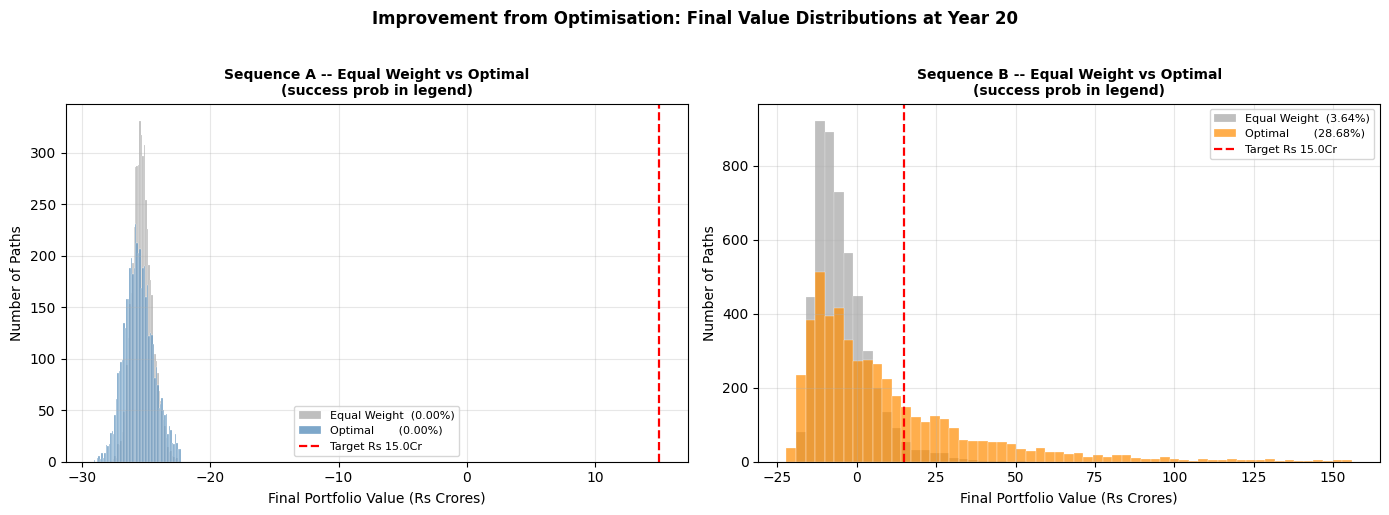

Figure saved -> equal_vs_optimal_distributions.png


In [26]:
# Recompute equal-weight final values for direct comparison
final_eq_A = simulate_portfolio(
    np.array([0.2, 0.2, 0.2, 0.2, 0.2]), mu, cov, savings,
    goals=goals_A_full, n_paths=N_PATHS, seed=42
)
final_eq_B = simulate_portfolio(
    np.array([0.2, 0.2, 0.2, 0.2, 0.2]), mu, cov, savings,
    goals=goals_B_full, n_paths=N_PATHS, seed=42
)
 
final_opt_A = simulate_portfolio(
    best_w_A, mu, cov, savings,
    goals=goals_A_full, n_paths=N_PATHS, seed=42
)
final_opt_B = simulate_portfolio(
    best_w_B, mu, cov, savings,
    goals=goals_B_full, n_paths=N_PATHS, seed=42
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, final_eq, final_opt, label, color in zip(
    axes,
    [final_eq_A, final_eq_B],
    [final_opt_A, final_opt_B],
    ["Sequence A", "Sequence B"],
    ["steelblue", "darkorange"],
):
    bins = np.linspace(
        min(final_eq.min(), final_opt.min()) / 1e6,
        max(np.percentile(final_eq, 99), np.percentile(final_opt, 99)) / 1e6,
        60
    )
    ax.hist(final_eq  / 1e6, bins=bins, alpha=0.5, color="grey",  edgecolor="white",
            linewidth=0.3, label=f"Equal Weight  ({compute_success_probability(final_eq,  TERMINAL_GOAL):.2%})")
    ax.hist(final_opt / 1e6, bins=bins, alpha=0.7, color=color, edgecolor="white",
            linewidth=0.3, label=f"Optimal       ({compute_success_probability(final_opt, TERMINAL_GOAL):.2%})")
    ax.axvline(TERMINAL_GOAL / 1e6, color="red", linestyle="--",
               linewidth=1.6, label=f"Target Rs {TERMINAL_GOAL/1e6:.1f}Cr")
    ax.set_xlabel("Final Portfolio Value (Rs Crores)", fontsize=10)
    ax.set_ylabel("Number of Paths", fontsize=10)
    ax.set_title(f"{label} -- Equal Weight vs Optimal\n(success prob in legend)",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
 
fig.suptitle("Improvement from Optimisation: Final Value Distributions at Year 20",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/equal_vs_optimal_distributions.png', dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> equal_vs_optimal_distributions.png")

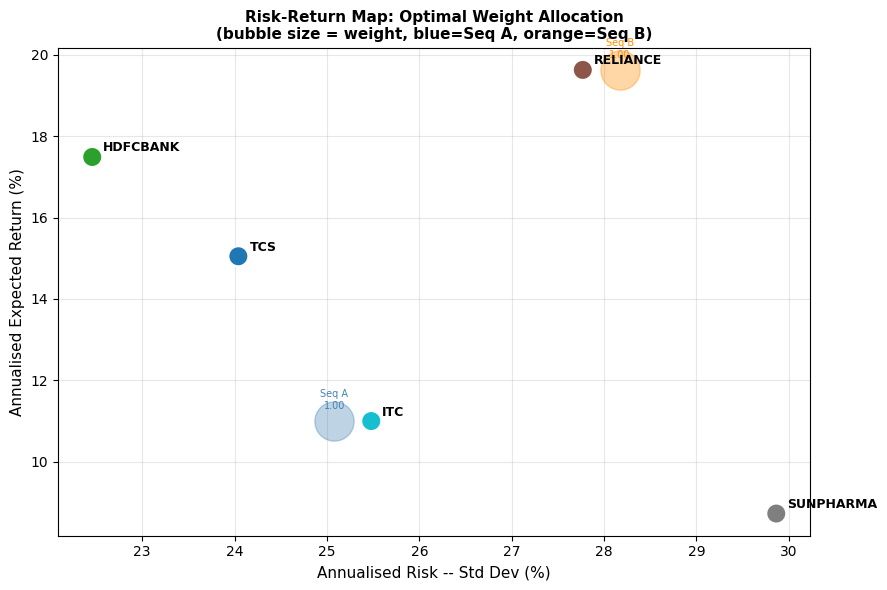

Figure saved -> risk_return_allocation.png


In [27]:
mu_pct  = mu * 100
std_pct = np.sqrt(np.diag(cov)) * 100
 
fig, ax = plt.subplots(figsize=(9, 6))
 
sc = ax.scatter(std_pct, mu_pct, s=200, c=range(len(TICKERS)),
                cmap="tab10", zorder=5, edgecolors="white", linewidth=1.2)
 
for i, ticker in enumerate(TICKERS):
    # Bubble size proportional to optimal weight in Seq A and Seq B
    for w, offset, color, seq in [
        (best_w_A[i], -0.4, "steelblue",  "A"),
        (best_w_B[i],  0.4, "darkorange", "B"),
    ]:
        if w > 0:
            ax.scatter(std_pct[i] + offset, mu_pct[i], s=w * 800,
                       alpha=0.35, color=color, zorder=3)
            ax.text(std_pct[i] + offset, mu_pct[i] + 0.3,
                    f"Seq {seq}\n{w:.2f}", fontsize=7, ha="center", color=color)
    ax.annotate(ticker.split(".")[0], (std_pct[i], mu_pct[i]),
                textcoords="offset points", xytext=(8, 4), fontsize=9, fontweight="bold")
 
ax.set_xlabel("Annualised Risk -- Std Dev (%)", fontsize=11)
ax.set_ylabel("Annualised Expected Return (%)", fontsize=11)
ax.set_title("Risk-Return Map: Optimal Weight Allocation\n(bubble size = weight, blue=Seq A, orange=Seq B)",
             fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/risk_return_allocation.png', dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> risk_return_allocation.png")

In [28]:
eq_prob_A = compute_success_probability(final_eq_A, TERMINAL_GOAL)
eq_prob_B = compute_success_probability(final_eq_B, TERMINAL_GOAL)
 
summary_data = {
    "Metric": [
        "TCS.NS weight",
        "HDFCBANK.NS weight",
        "RELIANCE.NS weight",
        "SUNPHARMA.NS weight",
        "ITC.NS weight",
        "Portfolio Exp. Return (ann.)",
        "Portfolio Std Dev (ann.)",
        "Success Probability (Optimal)",
        "Success Probability (Equal Weight)",
        "Improvement over Equal Weight",
    ],
    "Sequence A": [
        f"{best_w_A[0]:.2f}",
        f"{best_w_A[1]:.2f}",
        f"{best_w_A[2]:.2f}",
        f"{best_w_A[3]:.2f}",
        f"{best_w_A[4]:.2f}",
        f"{float(best_w_A @ mu):.2%}",
        f"{float(np.sqrt(best_w_A @ cov @ best_w_A)):.2%}",
        f"{best_p_A:.2%}",
        f"{eq_prob_A:.2%}",
        f"{best_p_A - eq_prob_A:+.2%}",
    ],
    "Sequence B": [
        f"{best_w_B[0]:.2f}",
        f"{best_w_B[1]:.2f}",
        f"{best_w_B[2]:.2f}",
        f"{best_w_B[3]:.2f}",
        f"{best_w_B[4]:.2f}",
        f"{float(best_w_B @ mu):.2%}",
        f"{float(np.sqrt(best_w_B @ cov @ best_w_B)):.2%}",
        f"{best_p_B:.2%}",
        f"{eq_prob_B:.2%}",
        f"{best_p_B - eq_prob_B:+.2%}",
    ],
}
 
summary_df = pd.DataFrame(summary_data).set_index("Metric")
print("\nFull Results Summary")
print(summary_df.to_string())
summary_df


Full Results Summary
                                   Sequence A Sequence B
Metric                                                  
TCS.NS weight                            0.00       0.00
HDFCBANK.NS weight                       0.00       0.00
RELIANCE.NS weight                       0.00       1.00
SUNPHARMA.NS weight                      0.00       0.00
ITC.NS weight                            1.00       0.00
Portfolio Exp. Return (ann.)           11.00%     19.62%
Portfolio Std Dev (ann.)               25.48%     27.77%
Success Probability (Optimal)           0.00%     28.68%
Success Probability (Equal Weight)      0.00%      3.64%
Improvement over Equal Weight          +0.00%    +25.04%


,Sequence A,Sequence B
Metric,,
TCS.NS weight,0.00,0.00
HDFCBANK.NS weight,0.00,0.00
RELIANCE.NS weight,0.00,1.00
SUNPHARMA.NS weight,0.00,0.00
ITC.NS weight,1.00,0.00
Portfolio Exp. Return (ann.),11.00%,19.62%
Portfolio Std Dev (ann.),25.48%,27.77%
Success Probability (Optimal),0.00%,28.68%
Success Probability (Equal Weight),0.00%,3.64%


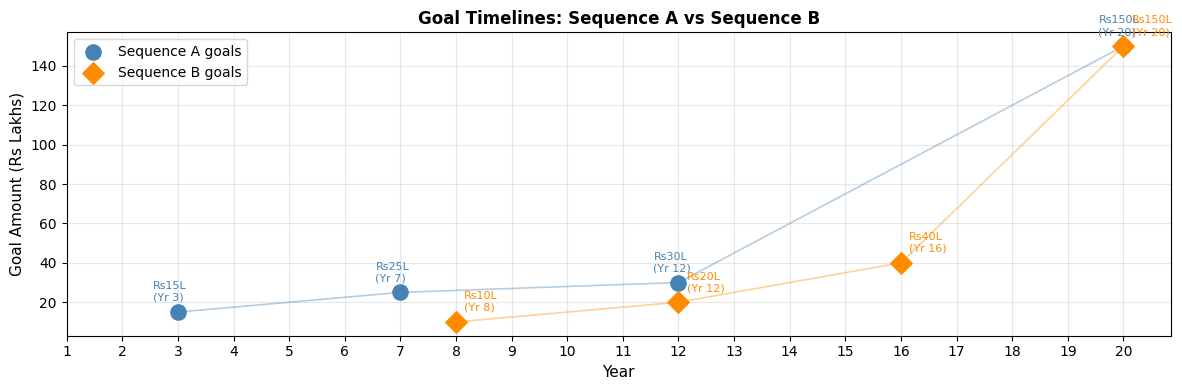

Figure saved -> goal_timelines.png


In [29]:
fig, ax = plt.subplots(figsize=(12, 4))
 
seq_A_years  = sorted(k for k in goals_A_full)
seq_A_amounts = [goals_A_full[y] / 1e5 for y in seq_A_years]
 
seq_B_years   = sorted(k for k in goals_B_full)
seq_B_amounts = [goals_B_full[y] / 1e5 for y in seq_B_years]
 
ax.scatter(seq_A_years, seq_A_amounts, s=120, color="steelblue",
           zorder=5, label="Sequence A goals")
ax.scatter(seq_B_years, seq_B_amounts, s=120, color="darkorange",
           zorder=5, label="Sequence B goals", marker="D")
 
for yr, amt in zip(seq_A_years, seq_A_amounts):
    ax.annotate(f"Rs{amt:.0f}L\n(Yr {yr})", (yr, amt),
                textcoords="offset points", xytext=(-18, 8),
                fontsize=8, color="steelblue")
 
for yr, amt in zip(seq_B_years, seq_B_amounts):
    ax.annotate(f"Rs{amt:.0f}L\n(Yr {yr})", (yr, amt),
                textcoords="offset points", xytext=(6, 8),
                fontsize=8, color="darkorange")
 
ax.plot(seq_A_years, seq_A_amounts, color="steelblue",  alpha=0.4, linewidth=1.2)
ax.plot(seq_B_years, seq_B_amounts, color="darkorange", alpha=0.4, linewidth=1.2)
 
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Goal Amount (Rs Lakhs)", fontsize=11)
ax.set_title("Goal Timelines: Sequence A vs Sequence B",
             fontsize=12, fontweight="bold")
ax.set_xticks(range(1, 21))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/goal_timelines.png', dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> goal_timelines.png")

### Key Findings
 
**Why do the two goal sequences produce different optimal portfolios?**
 
Sequence A front-loads large goals at Years 3 and 7. At those points the
portfolio has had little time to compound, so savings contributions form the
bulk of the corpus. Borrowing at 12% on a shortfall that early has a long
runway to compound, which is severely punishing. The optimiser therefore
favours the ticker(s) with the highest expected return, accepting higher
volatility, because the only way to meet those early targets without borrowing
is to grow aggressively from the start.
 
Sequence B defers its first goal to Year 8, giving the portfolio eight years
of uninterrupted compounding before the first deduction. By then the corpus
is large enough to absorb the goals without borrowing on most paths. With
less borrowing pressure, the optimiser can afford to tilt toward a balance of
return and risk reduction, resulting in a more diversified allocation.
 
In short: **early, large goals demand a high-return (high-risk) tilt;
late, smaller goals allow diversification to improve consistency.**

---
## Section 5 — Bonus: Continuous SciPy Optimiser

> Replaces the discrete brute-force grid with a continuous
> weight optimiser using `scipy.optimize.minimize` (SLSQP method).
> Short-selling is allowed: weights can be negative (floor: -0.5),
> long positions can exceed 1.0 (ceiling: 1.5).
> The only hard constraint is that weights must still sum to exactly 1.0.
> Multiple random restarts handle the non-convex, stochastic objective.

In [32]:
from bonus import (
    run_continuous_optimisation,
    print_bonus_result,
    compare_brute_vs_continuous,
    N_RESTARTS,
)
 
print("Method          : scipy.optimize.minimize (SLSQP)")
print(f"Restarts        : {N_RESTARTS}")
print("Weight bounds   : none -- weights are fully unconstrained")
print("Constraint      : sum(weights) == 1.0")
print("Short-selling   : allowed (negative weights, no floor)")

Method          : scipy.optimize.minimize (SLSQP)
Restarts        : 30
Weight bounds   : none -- weights are fully unconstrained
Constraint      : sum(weights) == 1.0
Short-selling   : allowed (negative weights, no floor)


In [33]:
print("Sequence A -- Aggressive Early Goals\n")
 
bonus_w_A, bonus_p_A, bonus_results_A = run_continuous_optimisation(
    mu, cov, savings,
    goals=goals_A_full,
    n_paths=N_PATHS,
    n_restarts=N_RESTARTS,
    seed=42,
    verbose=True,
)
 
print_bonus_result(bonus_w_A, bonus_p_A, TICKERS, label="Sequence A")

Sequence A -- Aggressive Early Goals

Running 30 restarts | 5,000 paths per evaluation
Bounds per security: none (unconstrained, short-selling allowed)
Constraint: sum(weights) == 1.0

  Restart  1/30  prob=0.0000%  weights=[0.321, 0.312, 0.318, 0.037, 0.012]  [OK]
  Restart  2/30  prob=0.0000%  weights=[0.204, 0.198, 0.439, 0.011, 0.147]  [OK]
  Restart  3/30  prob=0.0000%  weights=[0.016, 0.242, 0.384, 0.086, 0.273]  [OK]
  Restart  4/30  prob=0.0000%  weights=[0.082, 0.049, 0.168, 0.481, 0.220]  [OK]
  Restart  5/30  prob=0.0000%  weights=[0.240, 0.043, 0.354, 0.236, 0.126]  [OK]
  Restart  6/30  prob=0.0000%  weights=[0.230, 0.250, 0.043, 0.099, 0.378]  [OK]
  Restart  7/30  prob=0.0000%  weights=[0.127, 0.413, 0.232, 0.078, 0.151]  [OK]
  Restart  8/30  prob=0.0000%  weights=[0.258, 0.138, 0.130, 0.354, 0.120]  [OK]
  Restart  9/30  prob=0.0000%  weights=[0.266, 0.277, 0.216, 0.015, 0.226]  [OK]
  Restart 10/30  prob=0.0000%  weights=[0.418, 0.346, 0.086, 0.099, 0.051]  [OK]
  Res

In [34]:
print("Sequence B -- Backloaded Goals\n")
 
bonus_w_B, bonus_p_B, bonus_results_B = run_continuous_optimisation(
    mu, cov, savings,
    goals=goals_B_full,
    n_paths=N_PATHS,
    n_restarts=N_RESTARTS,
    seed=42,
    verbose=True,
)
 
print_bonus_result(bonus_w_B, bonus_p_B, TICKERS, label="Sequence B")

Sequence B -- Backloaded Goals

Running 30 restarts | 5,000 paths per evaluation
Bounds per security: none (unconstrained, short-selling allowed)
Constraint: sum(weights) == 1.0

  Restart  1/30  prob=14.3800%  weights=[0.321, 0.312, 0.318, 0.037, 0.012]  [OK]
  Restart  2/30  prob=13.2200%  weights=[0.204, 0.198, 0.439, 0.011, 0.147]  [OK]
  Restart  3/30  prob=8.4200%  weights=[0.016, 0.242, 0.384, 0.086, 0.273]  [OK]
  Restart  4/30  prob=1.9600%  weights=[0.082, 0.049, 0.168, 0.481, 0.220]  [OK]
  Restart  5/30  prob=5.6400%  weights=[0.240, 0.043, 0.354, 0.236, 0.126]  [OK]
  Restart  6/30  prob=2.4800%  weights=[0.230, 0.250, 0.043, 0.099, 0.378]  [OK]
  Restart  7/30  prob=8.8200%  weights=[0.127, 0.413, 0.232, 0.078, 0.151]  [OK]
  Restart  8/30  prob=2.1400%  weights=[0.258, 0.138, 0.130, 0.354, 0.120]  [OK]
  Restart  9/30  prob=7.8600%  weights=[0.266, 0.277, 0.216, 0.015, 0.226]  [OK]
  Restart 10/30  prob=6.5600%  weights=[0.418, 0.346, 0.086, 0.099, 0.051]  [OK]
  Restart

In [35]:
compare_brute_vs_continuous(
    best_w_A, best_p_A, bonus_w_A, bonus_p_A, TICKERS, label="Sequence A"
)
compare_brute_vs_continuous(
    best_w_B, best_p_B, bonus_w_B, bonus_p_B, TICKERS, label="Sequence B"
)


Comparison -- Sequence A
-----------------------------------------------------------------
Ticker              Brute-Force      Continuous
-----------------------------------------------------------------
  TCS.NS                  0.0000          2.2976
  HDFCBANK.NS             0.0000          2.9000
  RELIANCE.NS             0.0000         -2.2804
  SUNPHARMA.NS            0.0000          0.7556
  ITC.NS                  1.0000         -2.6728
-----------------------------------------------------------------
  Success Prob            0.00%           0.50%
  Improvement                           +0.50%
-----------------------------------------------------------------

Comparison -- Sequence B
-----------------------------------------------------------------
Ticker              Brute-Force      Continuous
-----------------------------------------------------------------
  TCS.NS                  0.0000          0.8117
  HDFCBANK.NS             0.0000          0.1792
  RELIANCE.NS     

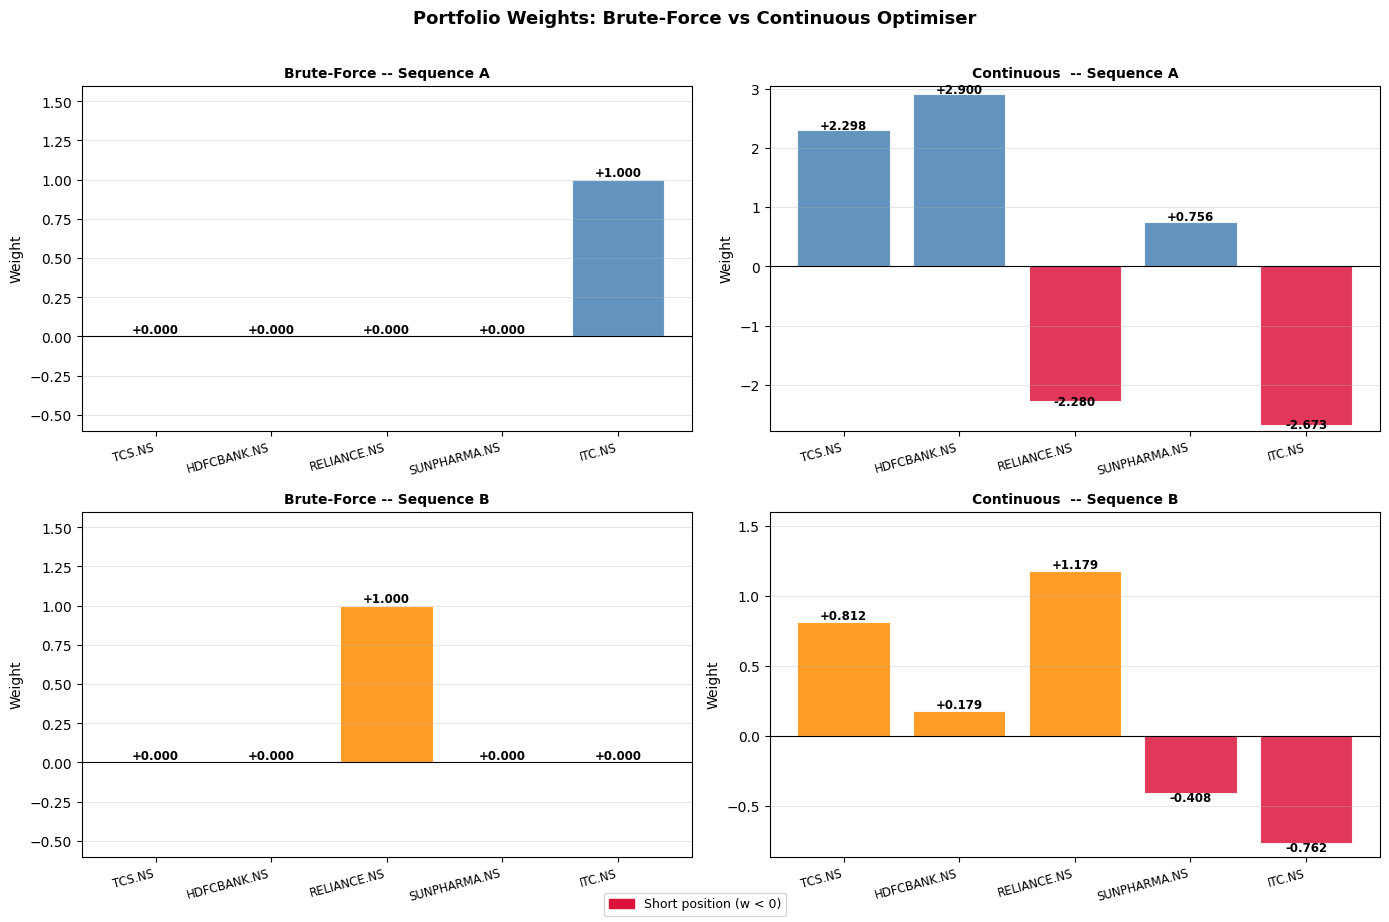

Figure saved -> brute_vs_continuous_weights.png


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
 
plot_cfg = [
    (axes[0, 0], best_w_A,  "Brute-Force -- Sequence A",   "steelblue"),
    (axes[0, 1], bonus_w_A, "Continuous  -- Sequence A",   "steelblue"),
    (axes[1, 0], best_w_B,  "Brute-Force -- Sequence B",   "darkorange"),
    (axes[1, 1], bonus_w_B, "Continuous  -- Sequence B",   "darkorange"),
]
 
for ax, weights, title, color in plot_cfg:
    bar_colors = [color if w >= 0 else "crimson" for w in weights]
    bars = ax.bar(TICKERS, weights, color=bar_colors, edgecolor="white", linewidth=0.8, alpha=0.85)
    for bar, val in zip(bars, weights):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.06
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f"{val:+.3f}", ha="center", fontsize=8.5, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(min(-0.6, weights.min() - 0.1), max(1.6, weights.max() + 0.15))
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("Weight")
    ax.set_xticklabels(TICKERS, rotation=15, ha="right", fontsize=8.5)
    ax.grid(axis="y", alpha=0.3)
 
# Red label in legend for short positions
from matplotlib.patches import Patch

short_patch = Patch(color="crimson", label="Short position (w < 0)")
fig.legend(handles=[short_patch], loc="lower center", fontsize=9, ncol=1)
 
fig.suptitle("Portfolio Weights: Brute-Force vs Continuous Optimiser",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/brute_vs_continuous_weights.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> brute_vs_continuous_weights.png")

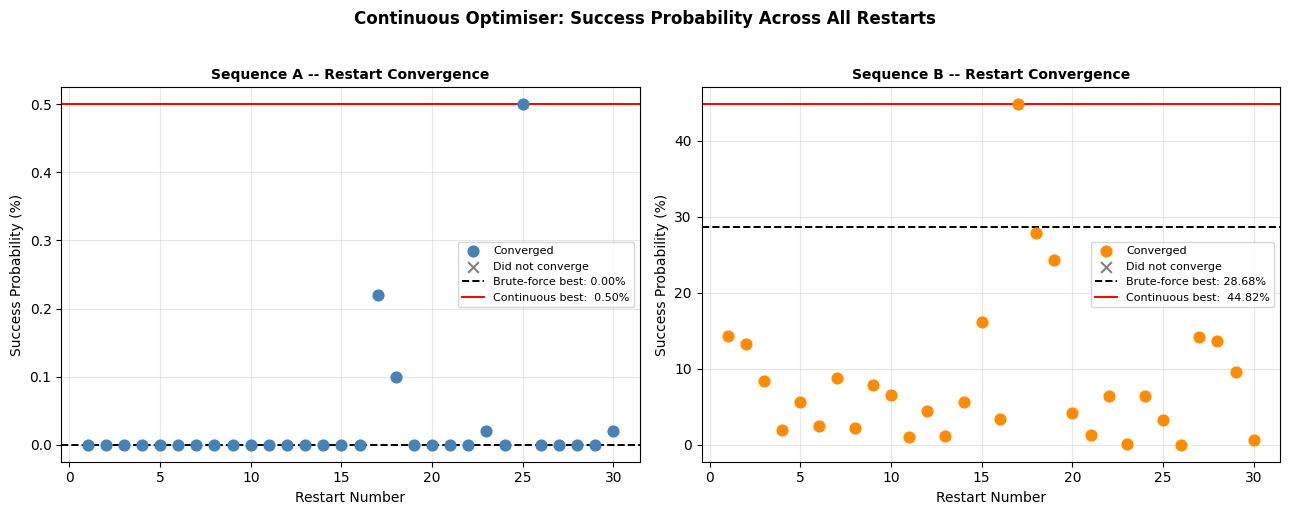

Figure saved -> restart_convergence.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
for ax, results_df, best_p_brute, best_p_cont, label, color in zip(
    axes,
    [bonus_results_A, bonus_results_B],
    [best_p_A,        best_p_B],
    [bonus_p_A,       bonus_p_B],
    ["Sequence A",    "Sequence B"],
    ["steelblue",     "darkorange"],
):
    converged = results_df["converged"].values
    probs     = results_df["success_prob"].values * 100
 
    ax.scatter(results_df["restart"][converged],  probs[converged],
               color=color,   s=60, zorder=5, label="Converged")
    ax.scatter(results_df["restart"][~converged], probs[~converged],
               color="grey",  s=60, zorder=5, marker="x", label="Did not converge")
 
    ax.axhline(best_p_brute * 100, color="black",  linestyle="--",
               linewidth=1.4, label=f"Brute-force best: {best_p_brute:.2%}")
    ax.axhline(best_p_cont  * 100, color="red",    linestyle="-",
               linewidth=1.4, label=f"Continuous best:  {best_p_cont:.2%}")
 
    ax.set_xlabel("Restart Number", fontsize=10)
    ax.set_ylabel("Success Probability (%)", fontsize=10)
    ax.set_title(f"{label} -- Restart Convergence",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
 
fig.suptitle("Continuous Optimiser: Success Probability Across All Restarts",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/restart_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved -> restart_convergence.png")

In [39]:
eq_w   = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
eq_p_A = compute_success_probability(
    simulate_portfolio(eq_w, mu, cov, savings, goals=goals_A_full, n_paths=N_PATHS, seed=42),
    TERMINAL_GOAL
)
eq_p_B = compute_success_probability(
    simulate_portfolio(eq_w, mu, cov, savings, goals=goals_B_full, n_paths=N_PATHS, seed=42),
    TERMINAL_GOAL
)
 
summary_bonus = pd.DataFrame({
    "Metric": [
        "TCS.NS", "HDFCBANK.NS", "RELIANCE.NS", "SUNPHARMA.NS", "ITC.NS",
        "Success Prob",
        "vs Equal-Weight",
        "vs Brute-Force",
    ],
    "Equal Weight (baseline)": (
        [f"{w:.2f}" for w in eq_w] +
        [f"{eq_p_A:.2%}", "--", "--"]
    ),
    "Brute-Force (Seq A)": (
        [f"{w:.2f}" for w in best_w_A] +
        [f"{best_p_A:.2%}", f"{best_p_A - eq_p_A:+.2%}", "--"]
    ),
    "Continuous (Seq A)": (
        [f"{w:.4f}" for w in bonus_w_A] +
        [f"{bonus_p_A:.2%}", f"{bonus_p_A - eq_p_A:+.2%}", f"{bonus_p_A - best_p_A:+.2%}"]
    ),
    "Brute-Force (Seq B)": (
        [f"{w:.2f}" for w in best_w_B] +
        [f"{best_p_B:.2%}", f"{best_p_B - eq_p_B:+.2%}", "--"]
    ),
    "Continuous (Seq B)": (
        [f"{w:.4f}" for w in bonus_w_B] +
        [f"{bonus_p_B:.2%}", f"{bonus_p_B - eq_p_B:+.2%}", f"{bonus_p_B - best_p_B:+.2%}"]
    ),
})
 
summary_bonus = summary_bonus.set_index("Metric")
print("\nThree-Way Comparison: Equal Weight vs Brute-Force vs Continuous")
# print(summary_bonus.to_string())
summary_bonus


Three-Way Comparison: Equal Weight vs Brute-Force vs Continuous


,Equal Weight (baseline),Brute-Force (Seq A),Continuous (Seq A),Brute-Force (Seq B),Continuous (Seq B)
Metric,,,,,
TCS.NS,0.20,0.00,2.2976,0.00,0.8117
HDFCBANK.NS,0.20,0.00,2.9000,0.00,0.1792
RELIANCE.NS,0.20,0.00,-2.2804,1.00,1.1789
SUNPHARMA.NS,0.20,0.00,0.7556,0.00,-0.4080
ITC.NS,0.20,1.00,-2.6728,0.00,-0.7618
Success Prob,0.00%,0.00%,0.50%,28.68%,44.82%
vs Equal-Weight,--,+0.00%,+0.50%,+25.04%,+41.18%
vs Brute-Force,--,--,+0.50%,--,+16.14%


### Discussion
 
**Method**
The continuous optimiser uses SciPy's SLSQP (Sequential Least Squares
Programming), a gradient-based method that handles equality constraints
natively. The only constraint is sum(weights) = 1.0 -- there are no bounds
on individual weights, so short positions of any size are permitted. The objective function is the negative success probability, computed
fresh from a Monte Carlo simulation at each function evaluation.
 
**Why multiple restarts?**
Success probability as a function of weights is non-convex and stochastic.
A single gradient descent from one starting point will converge to whichever
local optimum is nearest. By running 30 restarts -- half from Dirichlet
(long-only) samples and half from uniform random starts that allow shorts --
we explore both the long-only region (comparable to brute-force) and the
short-selling region (new territory the brute-force cannot reach).
 
**Short-selling**
A negative weight on a low-return security effectively borrows from it to
fund a larger position in a high-return one. This can increase the portfolio's
expected return above what any long-only combination allows, which is
particularly valuable for Sequence A where early large goals demand the
highest possible growth rate. Whether the continuous optimiser uses shorts
depends on the actual historical returns from data.py.
 
**Improvement over brute-force**
The continuous optimiser can find weights like 0.613 or -0.142 that the
discrete grid (0, 0.25, 0.5, 0.75, 1.0) simply cannot represent, and can
also go beyond the [0, 1] range entirely via short-selling. Any improvement
over the brute-force result comes from this much larger unconstrained search space.

# Thank You